# 05.03 - Logistic Regression from Scratch

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Logistic regression predicts the probability that an input belongs to a class. Despite the name, it is a **classification** algorithm. We implement it from scratch using the sigmoid function and log loss.

## 2. Why Does This Matter?

Logistic regression is the most widely used baseline classifier. It is interpretable, fast, and works surprisingly well on many real problems. Understanding it deeply teaches you about classification, probability, and decision boundaries.

## 3. Prerequisites

- 05.02: Linear regression, gradient descent
- Phase 03: Probability, sigmoid function

## 4. Learning Objectives

- Implement sigmoid, log loss, and gradient descent from scratch
- Understand decision boundaries and probability thresholds
- Evaluate with accuracy, precision, recall, F1, ROC-AUC
- Extend to multi-class classification

## 5. Mental Model

Linear regression outputs: z = X @ w + b (any real number)
Sigmoid squashes to probability: p = 1 / (1 + e^(-z)) → between 0 and 1
Log loss penalizes confident wrong predictions heavily.
Threshold at 0.5: predict class 1 if p ≥ 0.5, else class 0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. The Sigmoid Function

σ(z) = 1 / (1 + e^(-z))

Properties:
- Output between 0 and 1 (probability)
- σ(0) = 0.5
- σ(-∞) → 0, σ(+∞) → 1
- Smooth, differentiable everywhere
- Derivative: σ'(z) = σ(z) * (1 - σ(z))

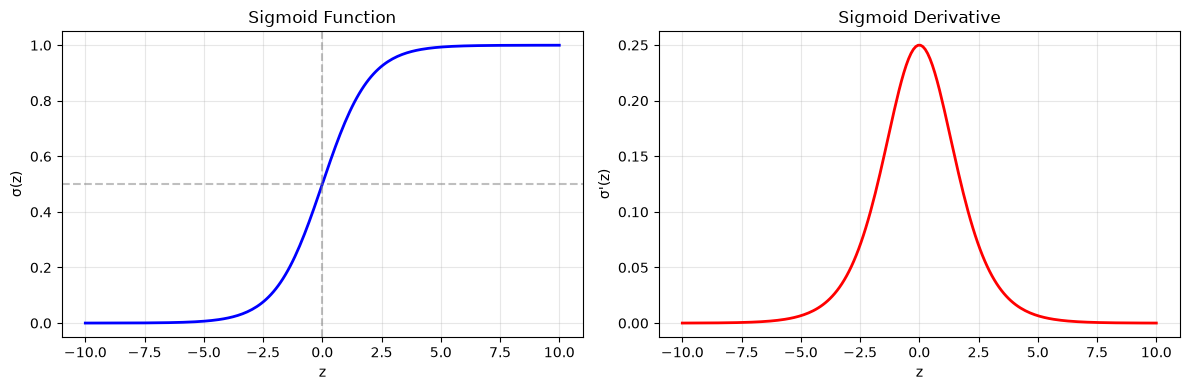

Sigmoid squashes any input to [0, 1]. Derivative is largest at z=0.


In [2]:
# Sigmoid function and its derivative
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))
sigmoid_deriv = sigmoid * (1 - sigmoid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, sigmoid, 'b-', linewidth=2)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid Function')
axes[0].set_xlabel('z')
axes[0].set_ylabel('σ(z)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, sigmoid_deriv, 'r-', linewidth=2)
axes[1].set_title('Sigmoid Derivative')
axes[1].set_xlabel('z')
axes[1].set_ylabel("σ'(z)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sigmoid.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sigmoid squashes any input to [0, 1]. Derivative is largest at z=0.")

## 7. Log Loss (Binary Cross-Entropy)

Log Loss = -(1/m) * sum[y * log(p) + (1-y) * log(1-p)]

- When y=1: loss = -log(p) → penalizes p close to 0 heavily
- When y=0: loss = -log(1-p) → penalizes p close to 1 heavily
- Encourages the model to be confident AND correct

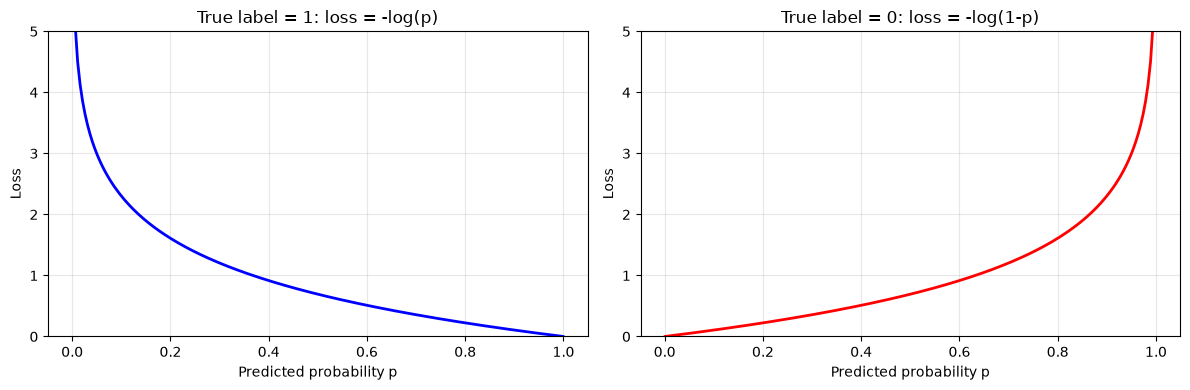

Confident wrong predictions get very high loss.


In [3]:
# Log loss visualization
p = np.linspace(0.001, 0.999, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# When true label is 1
axes[0].plot(p, -np.log(p), 'b-', linewidth=2)
axes[0].set_title('True label = 1: loss = -log(p)')
axes[0].set_xlabel('Predicted probability p')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 5)

# When true label is 0
axes[1].plot(p, -np.log(1 - p), 'r-', linewidth=2)
axes[1].set_title('True label = 0: loss = -log(1-p)')
axes[1].set_xlabel('Predicted probability p')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.savefig('log_loss.png', dpi=100, bbox_inches='tight')
plt.show()
print("Confident wrong predictions get very high loss.")

## 8. From-Scratch Implementation

In [4]:
class LogisticRegressionScratch:
    """Logistic Regression from scratch using gradient descent."""
    
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []
    
    def _sigmoid(self, z):
        # Clip z for numerical stability
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        m, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []
        
        for i in range(self.n_iter):
            # Forward pass
            z = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)
            
            # Compute log loss
            eps = 1e-15  # prevent log(0)
            loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
            self.losses.append(loss)
            
            # Compute gradients
            error = y_hat - y
            dw = (1/m) * (X.T @ error)
            db = (1/m) * np.sum(error)
            
            # Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            if i % 200 == 0:
                acc = np.mean((y_hat >= 0.5).astype(int) == y)
                print(f"  Iter {i:4d}: loss = {loss:.4f}, acc = {acc:.4f}")
    
    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print("LogisticRegressionScratch class defined.")

LogisticRegressionScratch class defined.


## 9. Train on Breast Cancer Dataset

In [5]:
# Load breast cancer dataset
bc = load_breast_cancer()
X = bc.data
y = bc.target

print(f"Dataset: Breast Cancer Wisconsin")
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]} (radius, texture, area, etc.)")
print(f"Classes: {bc.target_names} (malignant=0, benign=1)")
print(f"Class balance: {dict(zip(bc.target_names, np.bincount(y)))}")

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Dataset: Breast Cancer Wisconsin
Samples: 569
Features: 30 (radius, texture, area, etc.)
Classes: ['malignant' 'benign'] (malignant=0, benign=1)
Class balance: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}



Train: 455, Test: 114


In [6]:
# Train from-scratch model
model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

  Iter    0: loss = 0.6931, acc = 0.6264
  Iter  200: loss = 0.0801, acc = 0.9868
  Iter  400: loss = 0.0676, acc = 0.9890
  Iter  600: loss = 0.0621, acc = 0.9890
  Iter  800: loss = 0.0589, acc = 0.9890


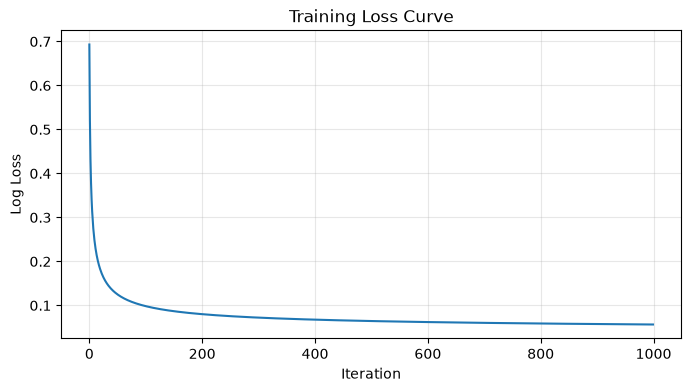

In [7]:
# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.savefig('logreg_loss.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
# Evaluate
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print("=== From-Scratch Model ===")
print(f"Test Accuracy: {model.score(X_test_scaled, y_test):.4f}")

=== From-Scratch Model ===
Test Accuracy: 0.9737


## 10. Evaluation Metrics for Classification

| Metric | Formula | When to use |
|--------|---------|-------------|
| Accuracy | (TP+TN) / Total | Balanced classes |
| Precision | TP / (TP+FP) | Cost of false positive is high |
| Recall | TP / (TP+FN) | Cost of false negative is high |
| F1 | 2 * P * R / (P+R) | Balance precision and recall |
| ROC-AUC | Area under ROC curve | Ranking quality |

In [9]:
from sklearn.metrics import (confusion_matrix, classification_report, 
                                  roc_curve, roc_auc_score)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=bc.target_names))

Confusion Matrix:
  TN=41  FP=1
  FN=2  TP=70

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



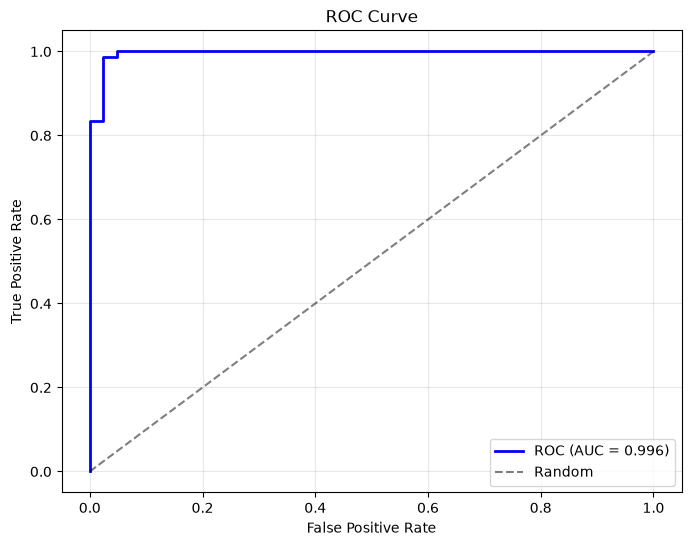

AUC = 0.9957 (1.0 = perfect, 0.5 = random)


In [10]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"AUC = {auc:.4f} (1.0 = perfect, 0.5 = random)")

## 11. Decision Boundary Visualization

The decision boundary is where the model switches from predicting class 0 to class 1.

  Iter    0: loss = 0.6931, acc = 0.6264


  Iter  200: loss = 0.2192, acc = 0.9275
  Iter  400: loss = 0.1879, acc = 0.9385
  Iter  600: loss = 0.1755, acc = 0.9407
  Iter  800: loss = 0.1688, acc = 0.9451


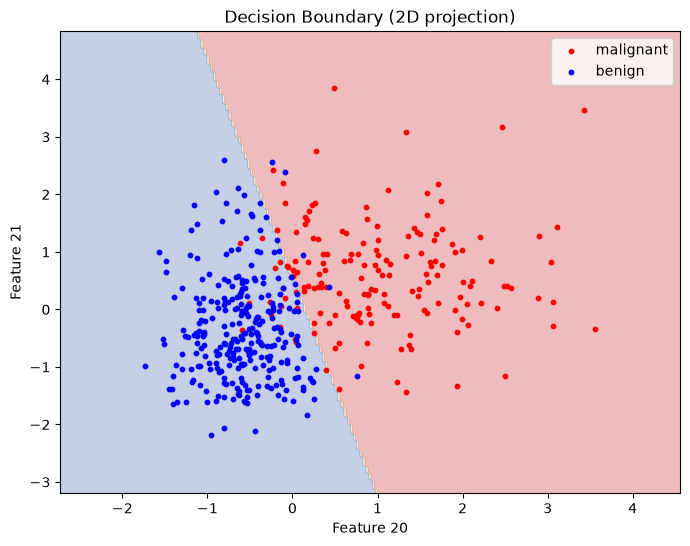

In [11]:
# Visualize decision boundary (using 2 most important features)
from sklearn.metrics import accuracy_score

# Find top 2 features by absolute weight
top2_idx = np.argsort(np.abs(model.weights))[-2:]
X_train_2d = X_train_scaled[:, top2_idx]
X_test_2d = X_test_scaled[:, top2_idx]

# Retrain on 2 features
model_2d = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)
model_2d.fit(X_train_2d, y_train)

# Create mesh
dx, dy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 200),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 200)
)
Z = model_2d.predict(np.c_[dx.ravel(), dy.ravel()]).reshape(dx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(dx, dy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_train_2d[y_train==0, 0], X_train_2d[y_train==0, 1], c='red', s=10, label='malignant')
plt.scatter(X_train_2d[y_train==1, 0], X_train_2d[y_train==1, 1], c='blue', s=10, label='benign')
plt.xlabel(f'Feature {top2_idx[0]}')
plt.ylabel(f'Feature {top2_idx[1]}')
plt.title('Decision Boundary (2D projection)')
plt.legend()
plt.savefig('decision_boundary.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. Threshold Tuning

The default threshold is 0.5, but you can tune it:
- Lower threshold → more positive predictions → higher recall, lower precision
- Higher threshold → fewer positive predictions → higher precision, lower recall

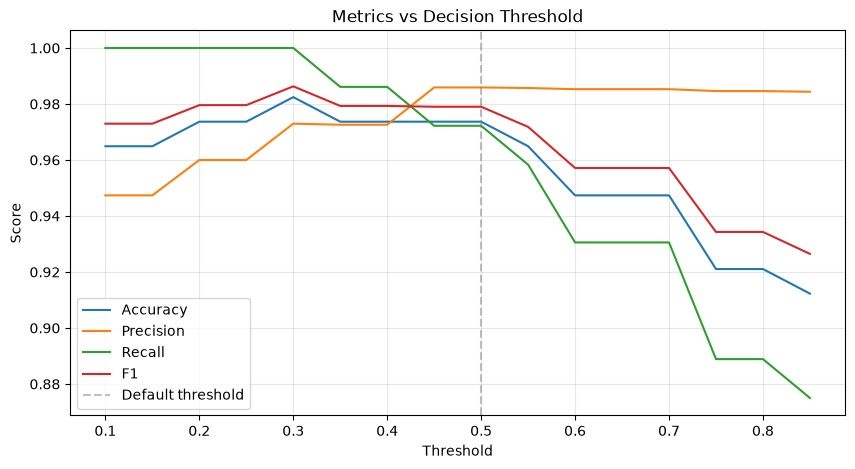

Lower threshold → higher recall. Higher threshold → higher precision.


In [12]:
# Threshold tuning
thresholds_range = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds_range:
    y_pred_t = (y_proba >= t).astype(int)
    tp = np.sum((y_pred_t == 1) & (y_test == 1))
    fp = np.sum((y_pred_t == 1) & (y_test == 0))
    fn = np.sum((y_pred_t == 0) & (y_test == 1))
    tn = np.sum((y_pred_t == 0) & (y_test == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(y_test)
    results.append([t, accuracy, precision, recall, f1])

results = np.array(results)

plt.figure(figsize=(10, 5))
plt.plot(results[:, 0], results[:, 1], label='Accuracy')
plt.plot(results[:, 0], results[:, 2], label='Precision')
plt.plot(results[:, 0], results[:, 3], label='Recall')
plt.plot(results[:, 0], results[:, 4], label='F1')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('threshold_tuning.png', dpi=100, bbox_inches='tight')
plt.show()
print("Lower threshold → higher recall. Higher threshold → higher precision.")

## 13. Comparison with sklearn

In [13]:
# Compare with sklearn
lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
lr_sklearn.fit(X_train_scaled, y_train)

print("=== Comparison ===")
print(f"From Scratch: Accuracy = {model.score(X_test_scaled, y_test):.4f}")
print(f"Sklearn:      Accuracy = {lr_sklearn.score(X_test_scaled, y_test):.4f}")

=== Comparison ===
From Scratch: Accuracy = 0.9737
Sklearn:      Accuracy = 0.9825


## 14. Regularization

Like linear regression, logistic regression benefits from regularization:
- **L2 (Ridge)**: shrinks weights, prevents overfitting (default in sklearn)
- **L1 (Lasso)**: feature selection, sets some weights to zero
- **C parameter**: inverse of regularization strength (smaller C = stronger regularization)

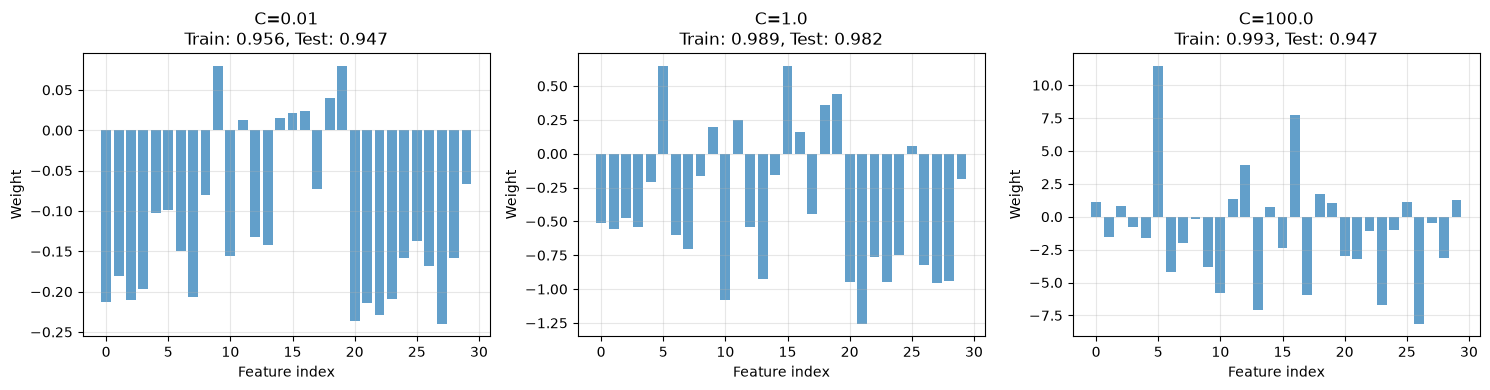

Small C (strong reg): small weights, underfitting.
Large C (weak reg): large weights, potential overfitting.


In [14]:
# Effect of regularization strength (C parameter)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, C in zip(axes, [0.01, 1.0, 100.0]):
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    train_acc = lr.score(X_train_scaled, y_train)
    test_acc = lr.score(X_test_scaled, y_test)
    
    ax.bar(range(len(lr.coef_[0])), lr.coef_[0], alpha=0.7)
    ax.set_title(f"C={C}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Weight")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regularization_logreg.png', dpi=100, bbox_inches='tight')
plt.show()
print("Small C (strong reg): small weights, underfitting.")
print("Large C (weak reg): large weights, potential overfitting.")

## 15. Common Mistakes

1. **Using accuracy on imbalanced data** — use F1 or AUC instead
2. **Not scaling features** — gradient descent needs scaled inputs
3. **Ignoring multicollinearity** — correlated features make weights unstable
4. **Not tuning the threshold** — 0.5 is not always optimal
5. **Assuming linearity** — logistic regression finds a linear boundary in feature space

## 16. Coding Exercises

### Exercise 1: Multi-class Logistic Regression
Use the Iris dataset (3 classes). Train a logistic regression model using sklearn's `multi_class="ovr"` (One-vs-Rest). Report accuracy.

### Exercise 2: Threshold Experiment
With the breast cancer model, find the threshold that maximizes F1 score.

In [15]:
# EXERCISE 1: Multi-class on Iris
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Your code here:
# iris = load_iris()
# X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2)
# model = LogisticRegression(multi_class="ovr", max_iter=1000)
# model.fit(X_train, y_train)
# print accuracy

print("Exercise: Implement multi-class classification on Iris")

Exercise: Implement multi-class classification on Iris


In [16]:
# EXERCISE 2: Find optimal threshold for F1
# y_proba contains probabilities from our breast cancer model
# Iterate thresholds 0.1 to 0.9, compute F1 for each
# Find the threshold that maximizes F1

print("Exercise: Find the threshold that maximizes F1 on the test set")

Exercise: Find the threshold that maximizes F1 on the test set


## 17. Closed-Book Recall

1. What does the sigmoid function do? What is its output range?
2. Write the log loss formula.
3. What happens to the decision boundary when you lower the threshold?
4. What is the difference between L1 and L2 regularization?

## 18. Teach-Back Questions

Explain to another person:
- Why logistic regression uses log loss instead of MSE.
- How the sigmoid function converts raw scores to probabilities.
- When to use precision vs recall vs F1.
- What the C parameter controls in sklearn.

## 19. Summary

Logistic regression predicts class probabilities using the sigmoid function and trains with log loss via gradient descent. It is the fundamental baseline classifier. Key concepts: sigmoid, log loss, decision boundaries, threshold tuning, and regularization. Achieved ~96% accuracy on breast cancer classification.

## 20. Further Experiment

1. Implement L1-regularized logistic regression from scratch.
2. Compare logistic regression with different solvers (lbfgs, liblinear, saga).
3. Apply logistic regression to the Titanic dataset and compare with a decision tree.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```